<h1 style="background-color: #2d90b467; padding: 10px; border-radius: 5px; font-weight: bold; color: #efeacf; text-align: center;">
    📊 Matplotlib and Seaborn
</h1>

### 📊 What is Data Visualization?

**Data Visualization** is the process of representing data in graphical 
form — using charts, graphs, and plots — to make patterns, trends, and 
relationships easier to understand. Numbers in a table can be hard to 
interpret at a glance, but the same data shown as a chart reveals 
insights almost instantly.

**Why it matters:**
- Makes patterns and trends visible that are hard to spot in raw numbers
- Helps compare values, categories, and distributions quickly
- Reveals outliers and anomalies in the data
- Communicates findings clearly to others (reports, presentations, dashboards)

**Common types of visualizations:**
- **Line Plot** — shows trends and changes over time
- **Bar Chart** — compares values across categories
- **Histogram** — shows the distribution of a single numeric variable
- **Scatter Plot** — shows the relationship between two numeric variables
- **Pie Chart** — shows proportions of a whole
- **Box Plot** — shows spread, median, and outliers
- **Heatmap** — shows correlation or intensity across a grid

**Libraries used:**
- **Matplotlib** — the foundational plotting library in Python, offering 
  full control over every element of a chart
- **Seaborn** — built on top of Matplotlib, provides cleaner default 
  styling and simpler syntax for statistical plots

---

### 📈 Introduction to Matplotlib

**Matplotlib** is the most widely used plotting library in Python and 
forms the foundation for most other visualization libraries (including 
Seaborn). It gives you full control over every element of a chart — 
colors, labels, axes, legends, sizes, and layout.

Most plotting is done through its `pyplot` module, which is conventionally 
imported as `plt`. It provides a simple, MATLAB-style interface where you 
build a plot step by step: create the chart, add labels and styling, then 
display it.

**Key points:**
- Works seamlessly with Pandas DataFrames and NumPy arrays
- Highly customizable — you can control nearly every visual detail
- Serves as the base layer that Seaborn builds on top of

##### Installing Matplotlib
Installs the library. Only needs to be run once — skip this if it's 
already installed in your environment.
```python
pip install matplotlib
```

##### Importing Matplotlib
Imports the `pyplot` module, conventionally aliased as `plt`. This is 
the standard import used in almost all Matplotlib code.
```python
import matplotlib.pyplot as plt
```


---

### 🌊 Introduction to Seaborn

**Seaborn** is a Python visualization library built on top of Matplotlib. 
It's designed specifically for statistical plotting, offering cleaner 
default styles, built-in color palettes, and simpler syntax for common 
chart types — especially ones that would take much more code to build 
in plain Matplotlib.

Unlike Matplotlib, Seaborn works especially well directly with Pandas 
DataFrames, letting you plot columns by name instead of manually 
extracting values.

**Key points:**
- Built on top of Matplotlib — every Seaborn plot is still a Matplotlib 
  figure underneath, so Matplotlib customization functions still work
- Great for statistical visualizations (distributions, correlations, 
  categorical comparisons)
- Cleaner, more attractive default styling out of the box
- Works directly with DataFrame columns (`x="col1", y="col2", data=df`)

##### Installing Seaborn
Installs the library. Only needs to be run once — skip this if it's 
already installed in your environment.
```python
pip install seaborn
```

##### Importing Seaborn
Imports Seaborn, conventionally aliased as `sns`.
```python
import seaborn as sns
```


---

### 🎯 Choosing the Right Chart

Picking the right chart type depends on **what question you're trying 
to answer** about your data. Using the wrong chart can make patterns 
harder to see or even misleading. Here's a quick guide:

| What you want to show | Best chart type |
|---|---|
| Trend or change over time | **Line Plot** |
| Compare values across categories | **Bar Chart** |
| Distribution of a single numeric variable | **Histogram** |
| Relationship between two numeric variables | **Scatter Plot** |
| Proportion of a whole | **Pie Chart** |
| Spread, median, and outliers | **Box Plot** |
| Frequency of categories | **Count Plot** |
| Correlation between multiple variables | **Heatmap** |

**A few rules of thumb:**
- If your data has a **time or sequence** component → Line Plot
- If you're comparing **categories** (like City or Gender) → Bar Chart or Count Plot
- If you want to see **how spread out** your data is → Histogram or Box Plot
- If you're checking whether **two numeric variables are related** (like 
  Attendance vs Percentage) → Scatter Plot
- If you want to see **parts of a whole** (like Pass vs Fail percentage) 
  → Pie Chart, though Bar Charts are often clearer for more than 2-3 categories
- Avoid using Pie Charts when you have many categories — they get hard to read

---

### 📊 Bar Chart

A **Bar Chart** is used to compare values across different categories. 
Each bar's height (or length) represents the value of that category, 
making it easy to see which categories are higher or lower at a glance.

**When to use it:** comparing a numeric value across categories — like 
average Percentage by City, or number of students per Class.

##### `plt.bar()` — Basic vertical bar chart
Creates a vertical bar chart with category names on the x-axis and 
values on the y-axis.
```python
import matplotlib.pyplot as plt

city_avg = df.groupby("City")["Percentage"].mean()

plt.bar(city_avg.index, city_avg.values)
plt.xlabel("City")
plt.ylabel("Average Percentage")
plt.title("Average Percentage by City")
plt.show()
```
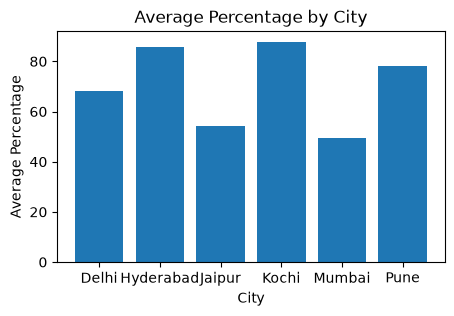

##### `plt.barh()` — Horizontal bar chart
Same as `plt.bar()` but bars run horizontally — useful when category 
names are long and would overlap on the x-axis.
```python
plt.barh(city_avg.index, city_avg.values)
plt.xlabel("Average Percentage")
plt.ylabel("City")
plt.title("Average Percentage by City")
plt.show()
```
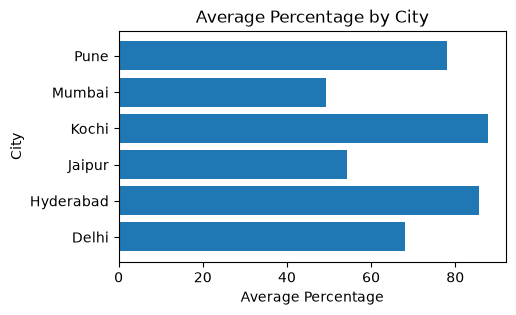

##### Customizing bar color
Changes the color of the bars using the `color` parameter.
```python
plt.bar(city_avg.index, city_avg.values, color="#1edf1e")
plt.show()
```
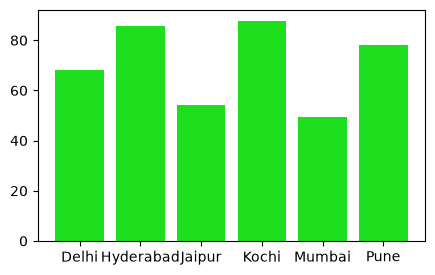

##### Rotating x-axis labels
Rotates category labels to prevent overlapping text when there are 
many categories or long names.
```python
plt.bar(city_avg.index, city_avg.values)
plt.xticks(rotation=45)
plt.show()
```
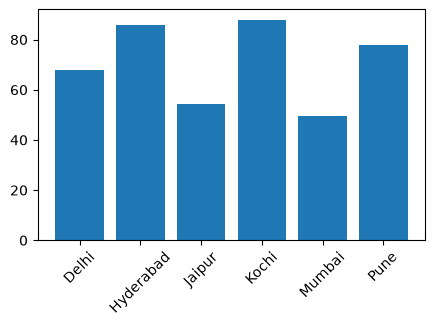

##### `sns.barplot()` — Seaborn bar chart
Seaborn's version of a bar chart — takes the raw dataframe directly 
and automatically calculates the average (mean) for each category, 
so you don't need to `groupby()` first.
```python
import seaborn as sns

sns.barplot(x="City", y="Percentage", data=df)
plt.title("Average Percentage by City")
plt.xticks(rotation=45)
plt.show()
```
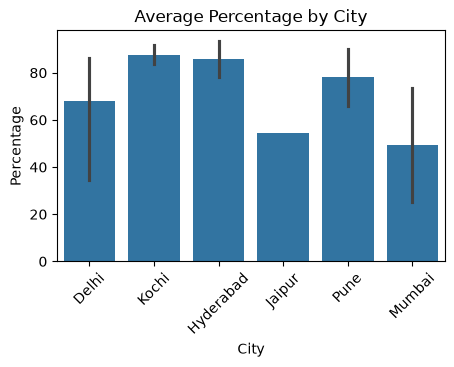

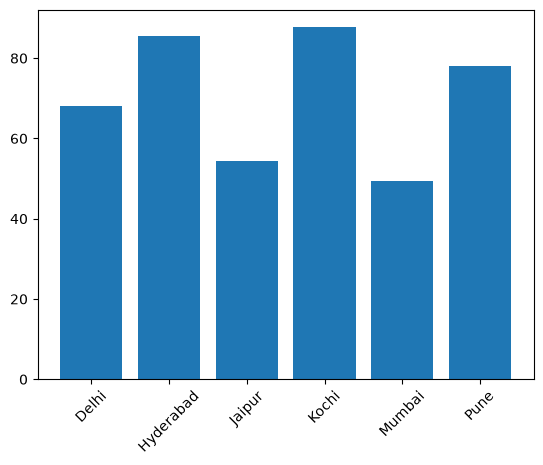
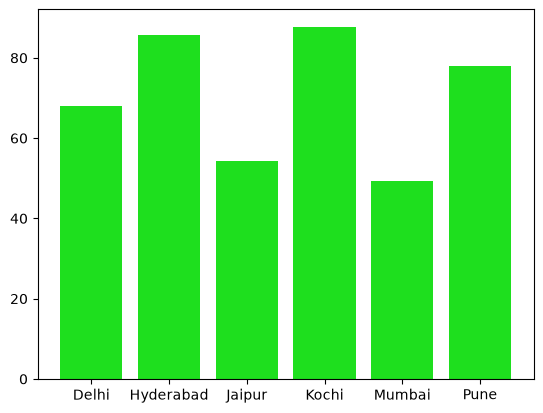
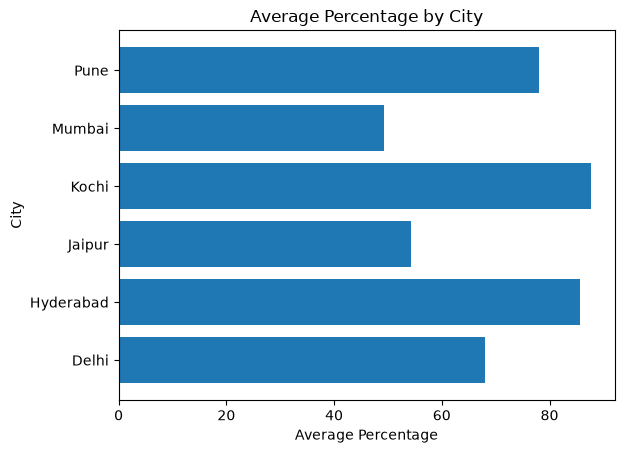
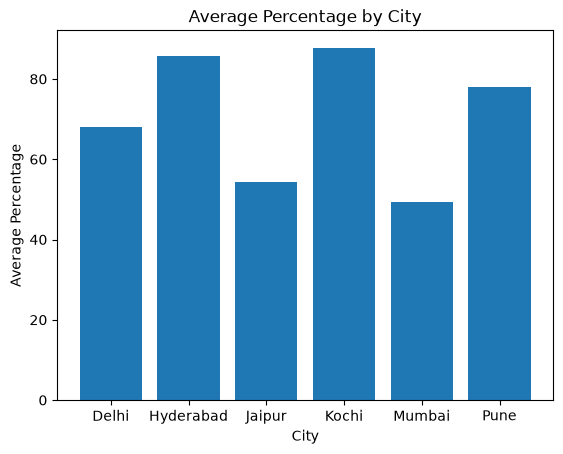
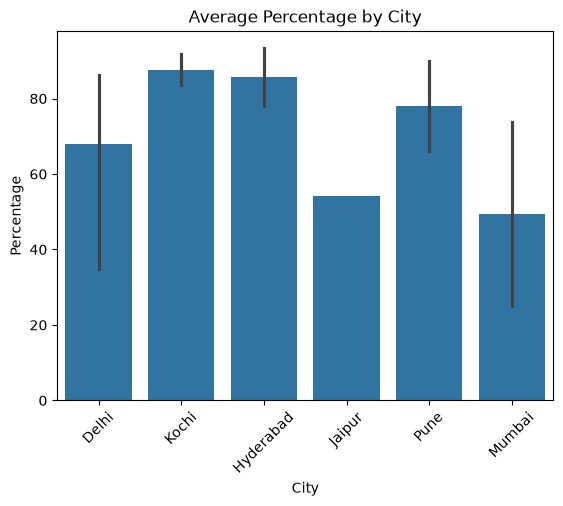

---

### 📈 Line Chart

A **Line Chart** is used to show trends and changes over a continuous 
sequence — most commonly over time. It connects individual data points 
with a line, making it easy to see the overall direction (increasing, 
decreasing, fluctuating) of the data.

**When to use it:** tracking how a value changes over time or across 
an ordered sequence — like monthly sales, daily temperature, or 
attendance trends over weeks.

*(Note: our student dataset doesn't have a time-based column, so this 
section uses a small example dataset instead, since line charts work 
best with sequential/time-series data.)*

##### Example data
```python
import matplotlib.pyplot as plt

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
sales = [200, 240, 210, 280, 300, 260]
```

##### `plt.plot()` — Basic line chart
Creates a line chart connecting the given x and y values with a line.
```python
plt.plot(months, sales)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")
plt.show()
```
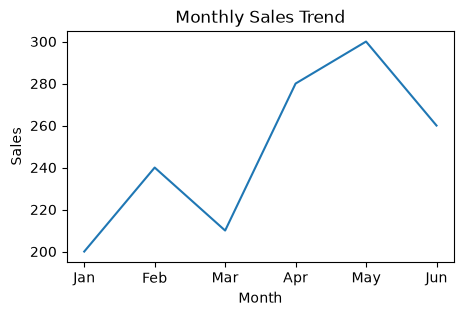

##### Adding markers
Adds a marker (dot, circle, etc.) at each data point along the line, 
making individual values easier to spot.
```python
plt.plot(months, sales, marker="o")
plt.show()
```
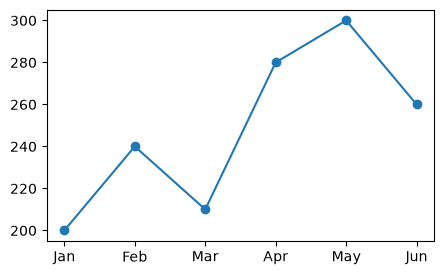

##### Customizing line style and color
Changes the line's color and style (solid, dashed, dotted).
```python
plt.plot(months, sales, color="green", linestyle="--", marker="o")
plt.show()
```
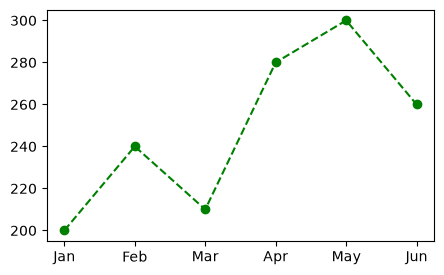

##### Plotting multiple lines
Plots more than one line on the same chart — useful for comparing 
trends across categories, like sales for two different products.
```python
product_a = [200, 240, 210, 280, 300, 260]
product_b = [180, 200, 230, 250, 270, 290]

plt.plot(months, product_a, marker="o", label="Product A")
plt.plot(months, product_b, marker="o", label="Product B")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Sales Trend by Product")
plt.legend()
plt.show()
```
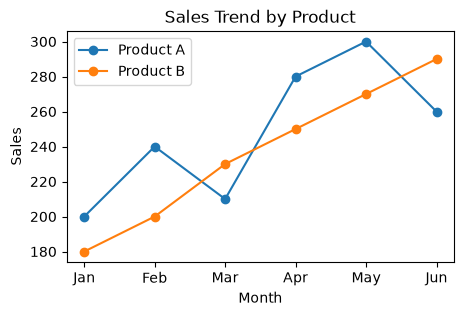

##### `sns.lineplot()` — Seaborn line chart
Seaborn's version of a line chart — works well with a dataframe if 
you have one, but also works with plain lists.
```python
import seaborn as sns

sns.lineplot(x=months, y=sales, marker="o")
plt.title("Monthly Sales Trend")
plt.show()
```
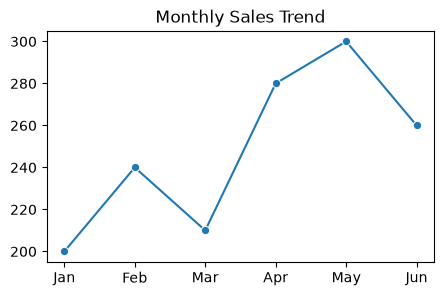

---

### 🥧 Pie Chart

A **Pie Chart** shows how a whole is divided into parts, with each 
slice representing a category's proportion of the total. It's best 
used when you have a small number of categories and want to show 
their relative share at a glance.

**When to use it:** showing proportions — like the Pass/Fail split, 
or the distribution of students across Grades. Avoid it when you have 
many categories (like City with 6 values), since slices become hard 
to read — a bar chart is usually clearer in that case.

##### `plt.pie()` — Basic pie chart
Creates a pie chart from the counts of a categorical column.
```python
import matplotlib.pyplot as plt

status_counts = df["Status"].value_counts()

plt.pie(status_counts, labels=status_counts.index)
plt.title("Pass vs Fail Distribution")
plt.show()
```
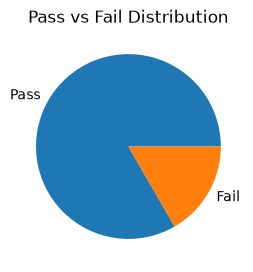

##### Adding percentage labels
Displays the percentage each slice represents, using `autopct`.
```python
plt.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%")
plt.title("Pass vs Fail Distribution")
plt.show()
```
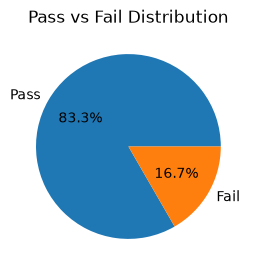

##### Customizing colors
Sets specific colors for each slice using the `colors` parameter.
```python
plt.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%",
        colors=["lightgreen", "salmon"])
plt.title("Pass vs Fail Distribution")
plt.show()
```
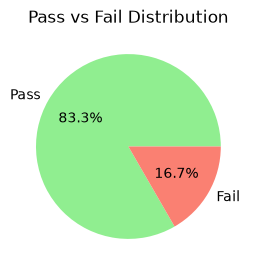

##### Exploding a slice
Pulls one slice slightly outward from the rest, useful for drawing 
attention to a specific category (e.g., highlighting "Fail").
```python
plt.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%",
        explode=[0, 0.1])
plt.title("Pass vs Fail Distribution")
plt.show()
```
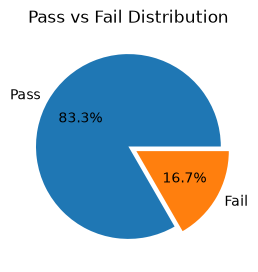

##### Making it a perfect circle
Ensures the pie chart renders as a circle rather than an oval — 
useful when the figure isn't square by default.
```python
plt.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%")
plt.axis("equal")
plt.show()
```
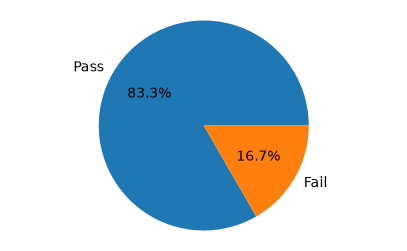



---

### 📊 Histogram

A **Histogram** shows the distribution of a single numeric variable by 
grouping values into ranges called "bins" and counting how many values 
fall into each bin. Unlike a bar chart (which compares categories), a 
histogram shows how values are spread out — whether they're clustered, 
skewed, or evenly distributed.

**When to use it:** understanding the spread/distribution of a numeric 
column — like seeing how Percentage or Attendance is distributed 
across all students.

##### `plt.hist()` — Basic histogram
Creates a histogram, automatically dividing the data into bins.
```python
import matplotlib.pyplot as plt

plt.hist(df["Percentage"])
plt.xlabel("Percentage")
plt.ylabel("Number of Students")
plt.title("Distribution of Percentage")
plt.show()
```
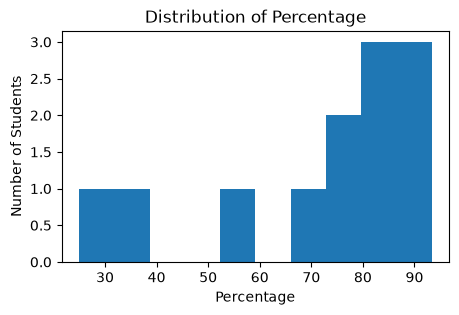

##### Controlling the number of bins
Sets how many bins (ranges) the data is divided into — fewer bins 
give a broader view, more bins show finer detail.
```python
plt.hist(df["Percentage"], bins=5)
plt.xlabel("Percentage")
plt.ylabel("Number of Students")
plt.title("Distribution of Percentage")
plt.show()
```
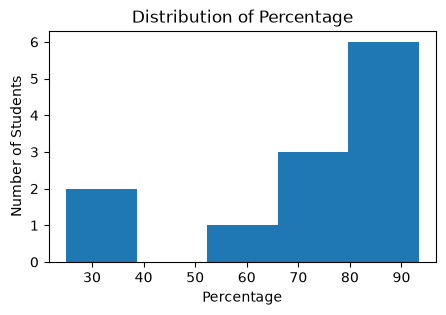

##### Customizing color and edges
Changes the bar color and adds an edge color/width for clearer 
separation between bins.
```python
plt.hist(df["Percentage"], bins=5, color="skyblue", edgecolor="black")
plt.show()
```
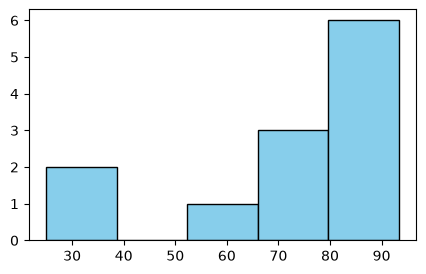

##### `sns.histplot()` — Seaborn histogram
Seaborn's version of a histogram — works directly with dataframe 
columns and can add a smoothed density curve with `kde=True`.
```python
import seaborn as sns

sns.histplot(df["Percentage"], bins=5, kde=True)
plt.title("Distribution of Percentage")
plt.show()
```
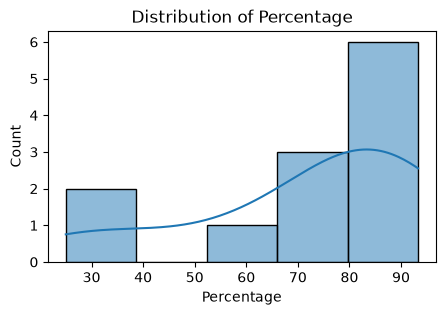

---

### 🔵 Scatter Plot

A **Scatter Plot** shows the relationship between two numeric variables 
by plotting each data point as a dot based on its x and y values. It's 
the go-to chart for spotting correlations, clusters, or outliers between 
two variables.

**When to use it:** checking whether two numeric columns are related — 
like whether higher Attendance is associated with higher Percentage.

##### `plt.scatter()` — Basic scatter plot
Creates a scatter plot with the first argument on the x-axis and the 
second on the y-axis.
```python
import matplotlib.pyplot as plt

plt.scatter(df["Attendance"], df["Percentage"])
plt.xlabel("Attendance")
plt.ylabel("Percentage")
plt.title("Attendance vs Percentage")
plt.show()
```
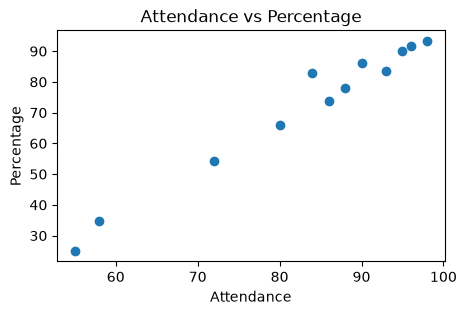

##### Customizing color and size
Changes the color and size of the dots using `color` and `s`.
```python
plt.scatter(df["Attendance"], df["Percentage"], color="purple", s=80)
plt.xlabel("Attendance")
plt.ylabel("Percentage")
plt.title("Attendance vs Percentage")
plt.show()
```
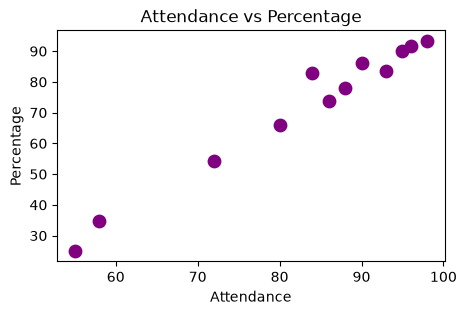

##### Coloring points by category
Colors each point differently based on a categorical column (e.g., 
Status), making it easy to see how groups differ.
```python
colors = df["Status"].map({"Pass": "green", "Fail": "red"})

plt.scatter(df["Attendance"], df["Percentage"], c=colors)
plt.xlabel("Attendance")
plt.ylabel("Percentage")
plt.title("Attendance vs Percentage (by Status)")
plt.show()
```
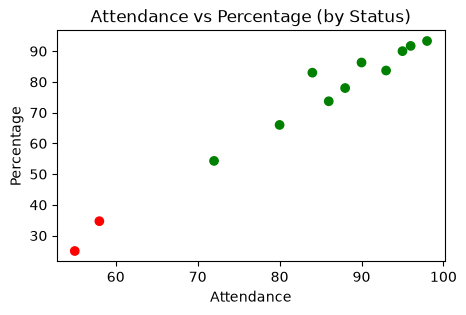

##### Adding a trend line
Fits and draws a straight line through the data to visualize the 
overall direction of the relationship, using `numpy`'s `polyfit`.
```python
import numpy as np

x = df["Attendance"]
y = df["Percentage"]

plt.scatter(x, y)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), color="red", linestyle="--")

plt.xlabel("Attendance")
plt.ylabel("Percentage")
plt.title("Attendance vs Percentage with Trend Line")
plt.show()
```
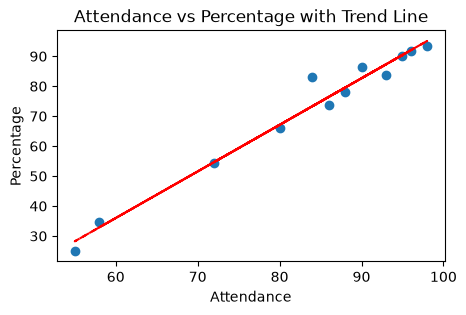

##### `sns.scatterplot()` — Seaborn scatter plot
Seaborn's version — works directly with dataframe columns and can 
automatically color points by category using `hue`.
```python
import seaborn as sns

sns.scatterplot(x="Attendance", y="Percentage", hue="Status", data=df)
plt.title("Attendance vs Percentage (by Status)")
plt.show()
```
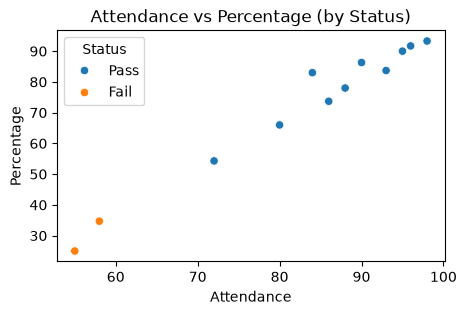

---

### 📦 Box Plot

A **Box Plot** (or box-and-whisker plot) shows the distribution of a 
numeric variable through its median, quartiles, and potential outliers. 
The "box" represents the middle 50% of the data (between the 25th and 
75th percentile), the line inside marks the median, and the "whiskers" 
extend to the typical range — with dots beyond them marking outliers.

**When to use it:** understanding the spread of a numeric column and 
spotting outliers — or comparing distributions across categories, 
like Percentage across different Classes.

##### `plt.boxplot()` — Basic box plot
Creates a box plot for a single numeric column.
```python
import matplotlib.pyplot as plt

plt.boxplot(df["Percentage"])
plt.ylabel("Percentage")
plt.title("Distribution of Percentage")
plt.show()
```
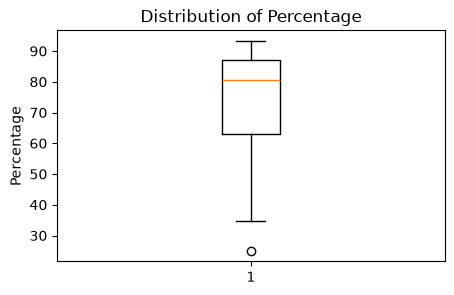

##### Horizontal box plot
Draws the box plot horizontally instead of vertically.
```python
plt.boxplot(df["Percentage"], vert=False)
plt.xlabel("Percentage")
plt.title("Distribution of Percentage")
plt.show()
```
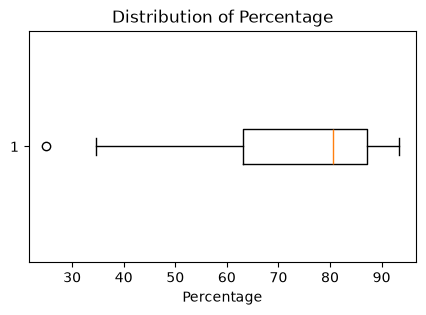

##### `sns.boxplot()` — Seaborn box plot
Seaborn's version — much easier for comparing a numeric column across 
categories, since it works directly with dataframe columns.
```python
import seaborn as sns

sns.boxplot(x="Class", y="Percentage", data=df)
plt.title("Percentage Distribution by Class")
plt.show()
```
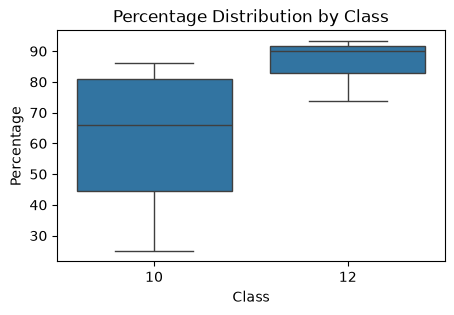

##### Grouped box plot with `hue`
Splits each category's box further by another categorical column — 
useful for comparing two dimensions at once.
```python
sns.boxplot(x="Class", y="Percentage", hue="Gender", data=df)
plt.title("Percentage Distribution by Class and Gender")
plt.show()
```
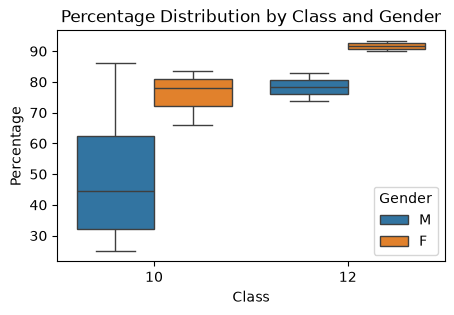

##### Identifying outliers
Points plotted individually beyond the whiskers represent outliers — 
in your dataset, Vikram (25.0%) and Rohan (34.7%) would likely show 
up this way since they're well below the rest of the class.
```python
sns.boxplot(y=df["Percentage"])
plt.title("Percentage - Outlier Check")
plt.show()
```
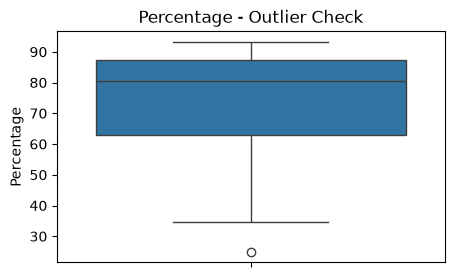

---

### 🔢 Count Plot

A **Count Plot** shows the frequency (count) of each category in a 
categorical column — essentially a bar chart where the height 
automatically represents how many times each category appears, 
without needing to calculate counts yourself first.

**When to use it:** seeing how many students fall into each category — 
like counting students per City, Gender, Class, or Status.

##### `sns.countplot()` — Basic count plot
Creates a count plot showing how many times each category appears 
in a column.
```python
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Status", data=df)
plt.title("Pass vs Fail Count")
plt.show()
```
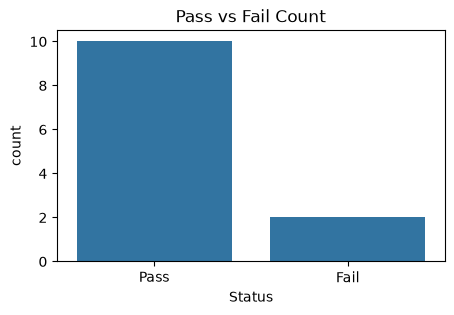

##### Count plot for a column with more categories
Works the same way regardless of how many categories a column has.
```python
sns.countplot(x="City", data=df)
plt.title("Number of Students per City")
plt.xticks(rotation=45)
plt.show()
```
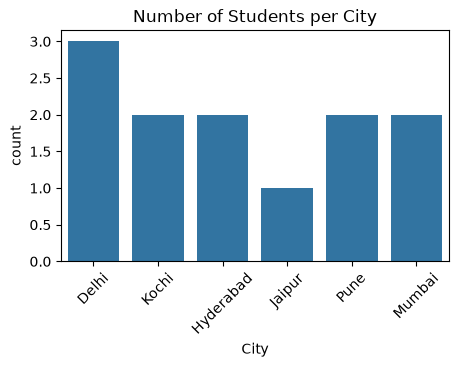

##### Grouped count plot with `hue`
Splits each category's count further by another categorical column — 
useful for comparing two dimensions at once, like Gender split by City.
```python
sns.countplot(x="City", hue="Gender", data=df)
plt.title("Students per City by Gender")
plt.xticks(rotation=45)
plt.show()
```
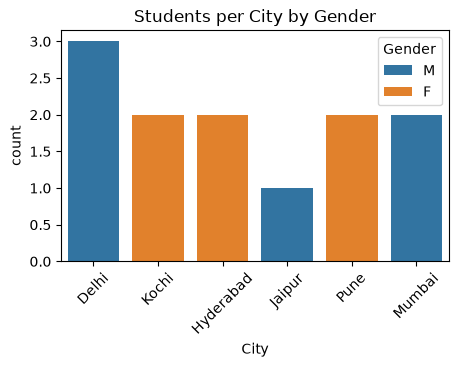

##### Horizontal count plot
Draws the bars horizontally instead of vertically — useful when 
category names are long.
```python
sns.countplot(y="City", data=df)
plt.title("Number of Students per City")
plt.show()
```
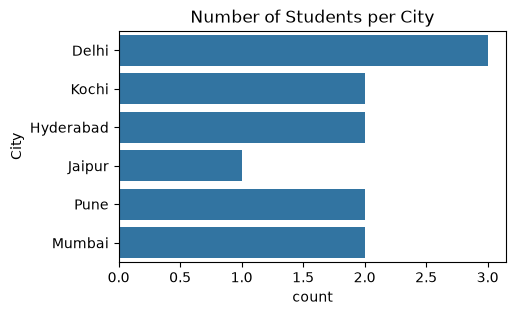

---

### 🔥 Heatmap

A **Heatmap** displays data in a grid where values are represented by 
color intensity — the higher or lower the value, the more intense or 
different the color. It's most commonly used to visualize **correlation** 
between numeric columns, making it easy to spot which variables move 
together.

**When to use it:** checking how numeric columns relate to each other — 
like seeing whether Attendance, Percentage, and subject marks are 
correlated.

##### `.corr()` — Calculating correlation
Before plotting, you need a correlation matrix — this calculates the 
correlation coefficient (between -1 and 1) between every pair of 
numeric columns.
```python
correlation = df[["Maths", "Science", "English", "Attendance", "Percentage"]].corr()
print(correlation)
```

##### `sns.heatmap()` — Basic heatmap
Plots the correlation matrix as a heatmap, with color representing 
the strength of correlation between each pair.
```python
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlation)
plt.title("Correlation Heatmap")
plt.show()
```
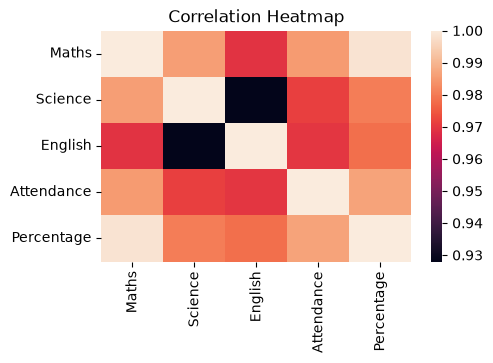

##### Adding value annotations
Displays the actual correlation numbers inside each cell using 
`annot=True` — makes the heatmap much easier to read precisely.
```python
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()
```
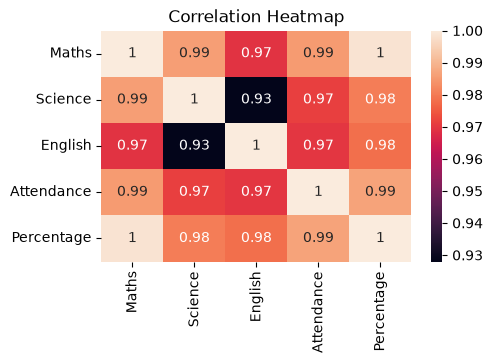

##### Customizing color scheme
Changes the heatmap's color palette using `cmap`.
```python
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
```
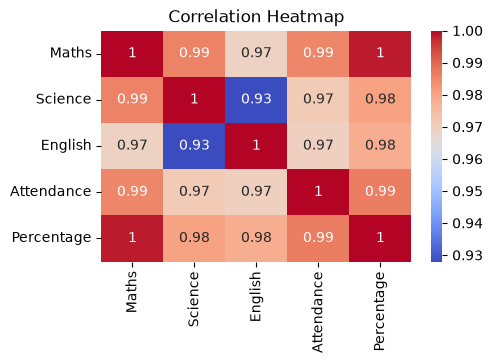

##### Interpreting the heatmap
- Values close to **+1** → strong positive correlation (both increase together)
- Values close to **-1** → strong negative correlation (one increases as the other decreases)
- Values close to **0** → little to no correlation
- In your dataset, expect Attendance and Percentage to show a fairly strong positive correlation, since low-attendance students (Vikram, Rohan) also had the lowest percentages

---

### 🖥️ Full Dashboard

Instead of viewing charts one at a time, a **dashboard** combines multiple 
plots into a single figure using subplots — giving a complete picture of 
the dataset at a glance. This is typically the final step in a 
visualization notebook, pulling together the most useful charts from 
earlier sections.

##### `plt.subplots()` — Creating a grid of plots
Creates a figure with a grid of subplots (2 rows × 2 columns here), 
returning both the overall figure and an array of individual axes to 
plot on.
```python
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
```

##### Plot 1: Pass vs Fail Count
```python
sns.countplot(x="Status", data=df, ax=axes[0,0])
axes[0,0].set_title("Pass vs Fail Count")
```

##### Plot 2: Average Percentage by City
```python
city_avg = df.groupby("City")["Percentage"].mean().sort_values()
axes[0,1].bar(city_avg.index, city_avg.values, color="skyblue")
axes[0,1].set_title("Average Percentage by City")
axes[0,1].tick_params(axis='x', rotation=45)
```

##### Plot 3: Attendance vs Percentage
```python
sns.scatterplot(x="Attendance", y="Percentage", hue="Status", data=df, ax=axes[1,0])
axes[1,0].set_title("Attendance vs Percentage")
```

##### Plot 4: Percentage Distribution by Class
```python
sns.boxplot(x="Class", y="Percentage", data=df, ax=axes[1,1])
axes[1,1].set_title("Percentage Distribution by Class")
```

##### Finalizing and saving the dashboard
`tight_layout()` prevents titles/labels from overlapping between 
subplots, and `savefig()` exports the whole dashboard as a single image 
— perfect for embedding in your README.
```python
plt.tight_layout()
plt.savefig("dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
```
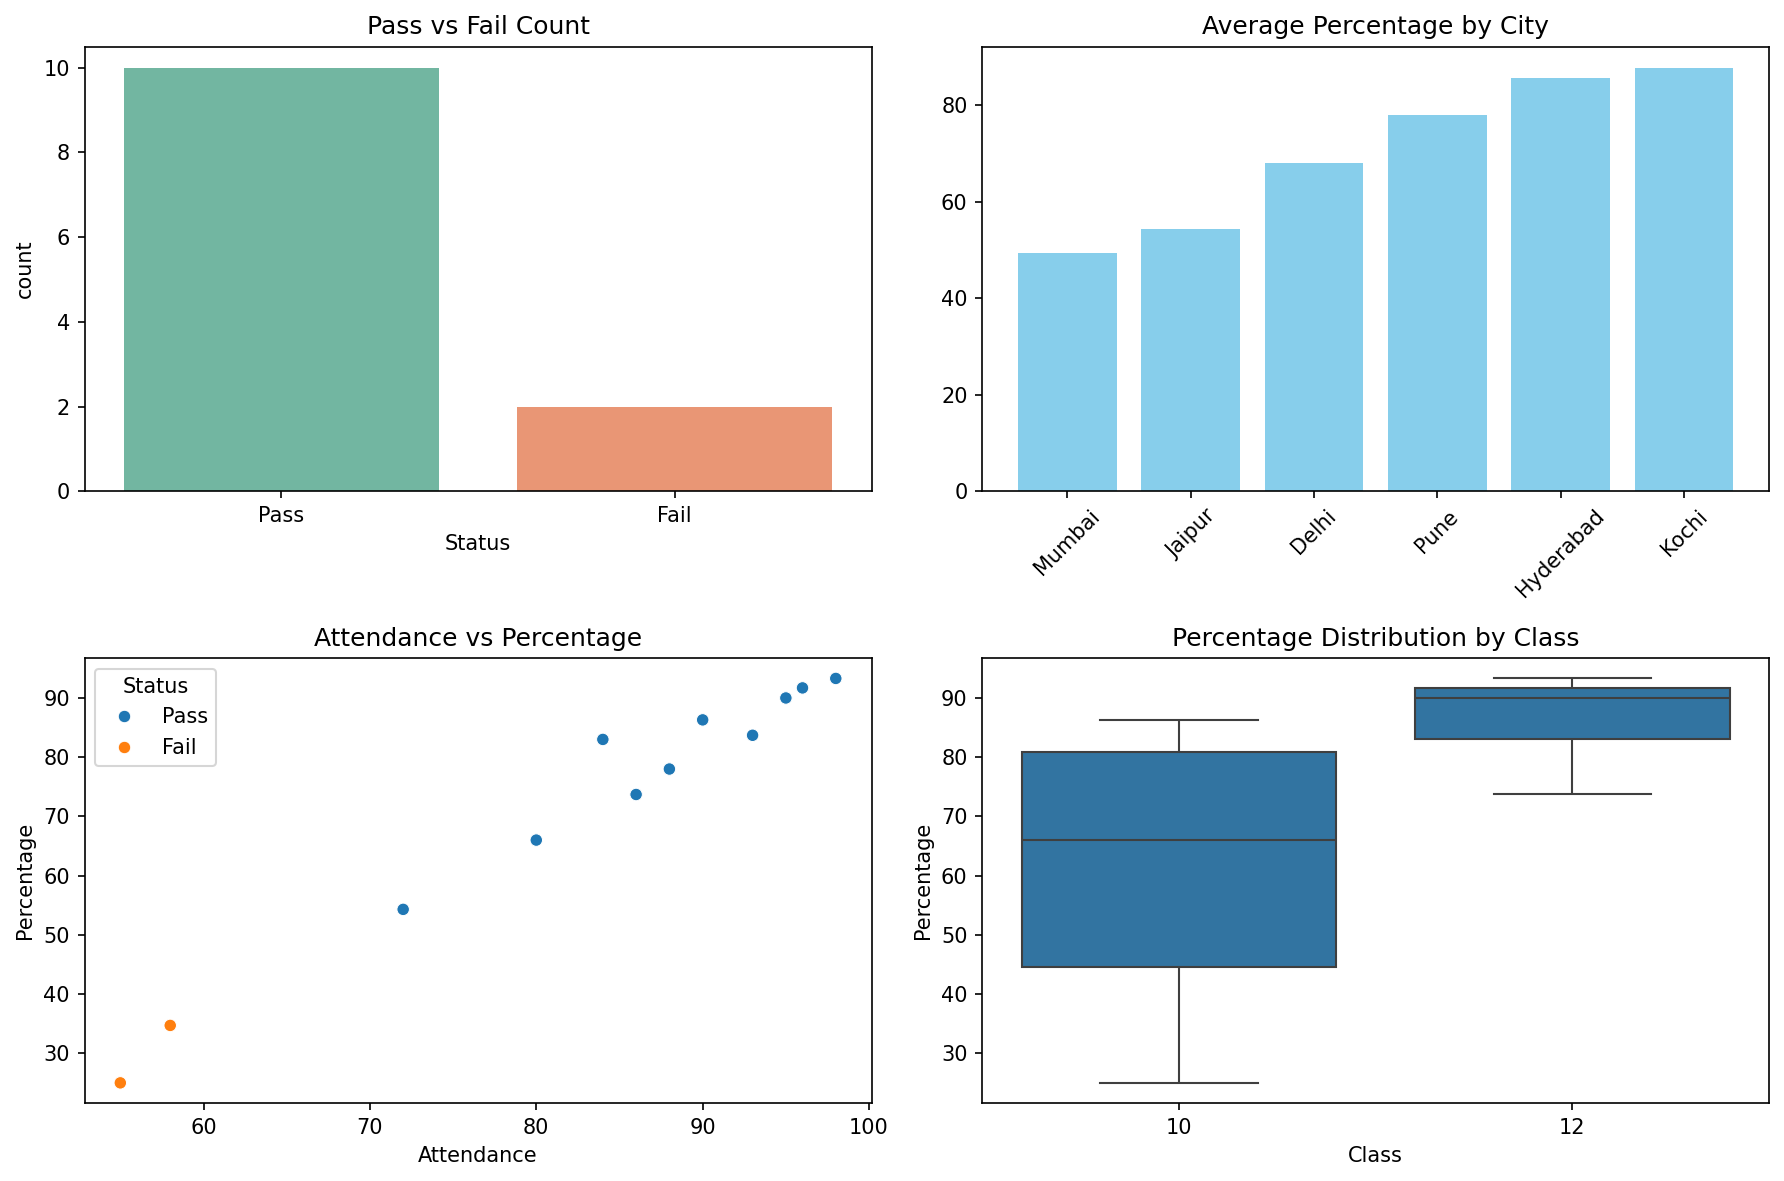

**What this dashboard reveals at a glance:**
- 10 students passed, 2 failed
- Kochi and Hyderabad have the highest average Percentage; Mumbai and Jaipur the lowest
- Attendance and Percentage show a clear positive relationship — both failing students also had the lowest attendance
- Class 12 students have a noticeably tighter, higher Percentage spread than Class 10

---
---